In [224]:
#!pip install openpyxl
#anndata needs to be 0.8.0
#!pip install -U kaleido
from glob import glob
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import anndata
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
import tarfile
import seaborn as sns
import torch

from collections import OrderedDict
import pickle
#import scrublet as scr
import scipy.io
import matplotlib.pyplot as plt
import os

In [225]:
import plotly

In [226]:
tcell_ann_concat = anndata.read_h5ad('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/anndata_file/tcell_ann_concat_Tcell_only_Migration.h5ad')

In [227]:
### Remove small clusters
# Get the value counts
cluster_counts = tcell_ann_concat.obs['leiden_0.5'].value_counts()

# Filter out clusters with counts lower than 200
filtered_clusters = cluster_counts[cluster_counts >= 200]

# Get the names of the clusters to keep
clusters_to_keep = filtered_clusters.index

# Filter the AnnData object to keep only the cells in those clusters
filtered_tcell_ann_concat = tcell_ann_concat[tcell_ann_concat.obs['leiden_0.5'].isin(clusters_to_keep)]

# Optionally, view the filtered counts
filtered_counts = filtered_tcell_ann_concat.obs['leiden_0.5'].value_counts()
filtered_counts

tcell_ann_concat = filtered_tcell_ann_concat

new_cluster_names = ['CD8+ Effector T cells','CD4+ Effector T cells','CD8+ Tissue Resident Memory T cells', "CD4+ Central Memory T cells","CD8+ Cytotoxic Unconventional T cells",'Low CD3',"CD8+ Proliferating T cells","CD4+ Regulatory T cells",'CD8+ Homeostatic Unconventional T cells'
]
tcell_ann_concat.rename_categories('leiden_0.5', new_cluster_names)



/Users/lingting/ENTER/envs/mrvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1071: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



In [228]:
Mobile = tcell_ann_concat[tcell_ann_concat.obs['Migration_all'].isin(['IE_Stationary', 'LP_Stationary', 'Mobile'])]

In [229]:
Mobile = Mobile[Mobile.obs['leiden_0.5'].isin(['CD8+ Effector T cells','CD8+ Tissue Resident Memory T cells',"CD8+ Proliferating T cells"])]

In [230]:
Mobile.obs['SampleID_leiden_0.5'] = Mobile.obs['leiden_0.5'].astype(str)+'_'+Mobile.obs['SampleID'].astype(str)

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/638004082.py:1: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



In [231]:
Mobile.obs['Migration_all']

AAACGGGAGACAGAGA-1    LP_Stationary
AAACGGGGTTATCCGA-1    LP_Stationary
AAAGTAGAGCTAGGCA-1    LP_Stationary
AAAGTAGTCGCCAGCA-1    LP_Stationary
AACCATGGTTGTGGCC-1    LP_Stationary
                          ...      
TGAGCATAGCGGCTTC-1    IE_Stationary
TGATTTCAGGCCGAAT-1    IE_Stationary
TGCCCTAAGTTGTCGT-1    IE_Stationary
TGGGAAGAGGTGACCA-1    IE_Stationary
TTGAACGGTTCAACCA-1    IE_Stationary
Name: Migration_all, Length: 10870, dtype: category
Categories (3, object): ['IE_Stationary', 'LP_Stationary', 'Mobile']

In [232]:
Mobile.uns['Migration_all_colors'] = ['#1f77b4','#ff7f0e','#9467bd']

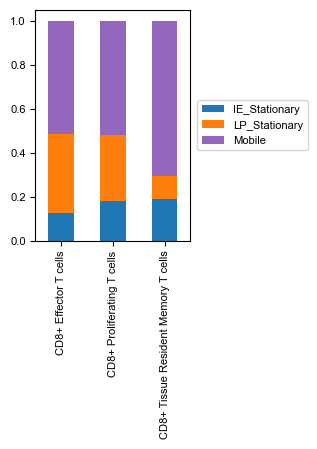

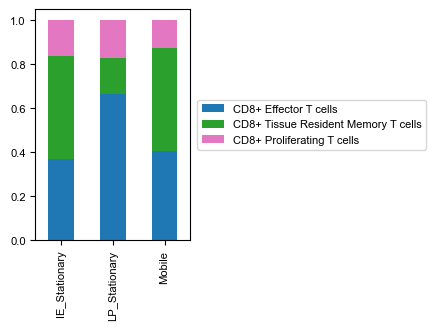

In [233]:
from copy import deepcopy
from matplotlib import rcParams
from statannotations.Annotator import Annotator
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

mpl.rcParams.update({
    'font.size': 8,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (2,3),  # Set default figure size to 3×3 inches
    'lines.linewidth': 1  # Set default line width to 1
})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size
obs_1 = 'PatientID_Grade'
obs_2 = 'leiden_0.5'

# Assuming adata is already defined and contains the necessary data
obs_1 = 'leiden_0.5'
obs_2 = 'Migration_all'
num = 1

for adata in [Mobile]:
    n_categories = {x: len(adata.obs[x].cat.categories) for x in [obs_1, obs_2]}
    df = adata.obs[[obs_2, obs_1]].values

    obs2_clusters = adata.obs[obs_2].cat.categories.tolist()
    obs1_clusters = adata.obs[obs_1].cat.categories.tolist()

    obs1_to_obs2 = {k: np.zeros(len(obs2_clusters), dtype="i")
                    for k in obs1_clusters}
    obs2_to_obs1 = {k: np.zeros(len(obs1_clusters), dtype="i")
                    for k in obs2_clusters}
    for b, l in df:
        obs2_to_obs1[b][obs1_clusters.index(str(l))] += 1
        obs1_to_obs2[l][obs2_clusters.index(str(b))] += 1
    obs2_to_obs1_array = np.zeros((len(obs2_clusters), len(obs1_clusters)))
    obs1_to_obs2_array = np.zeros((len(obs1_clusters), len(obs2_clusters)))
    for i, k in enumerate(obs2_clusters):
        obs2_to_obs1_array[i, :] = deepcopy(obs2_to_obs1[k])
    for i, k in enumerate(obs1_clusters):
        obs1_to_obs2_array[i, :] = deepcopy(obs1_to_obs2[k])

    sums = np.sum(obs2_to_obs1_array, 0)
    for col in range(np.size(obs2_to_obs1_array, 1)):
        for row in range(np.size(obs2_to_obs1_array, 0)):
            obs2_to_obs1_array[row, col] = obs2_to_obs1_array[row, col] / sums[col]

    sums2 = np.sum(obs1_to_obs2_array, 0)
    for col in range(np.size(obs1_to_obs2_array, 1)):
        for row in range(np.size(obs1_to_obs2_array, 0)):
            obs1_to_obs2_array[row, col] = obs1_to_obs2_array[row, col] / sums2[col]

    df_obs2 = pd.DataFrame(obs2_to_obs1_array)
    df_obs2.index = obs2_clusters
    df_obs2.columns = obs1_clusters

    # Sort columns if necessary
    sorter = sorted(obs1_clusters)
    df_obs2 = df_obs2.reindex(columns=sorter)

    df_obs2.T.plot(kind="bar", stacked=True, color=adata.uns[obs_2 + '_colors'])
    plt.legend(bbox_to_anchor=(1.01, 0.5), loc='center left')
    plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/conventional_mobile_bar_plot.png', dpi=300, bbox_inches='tight', transparent = True)  # Save PNG
    plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/conventional_mobile_bar_plot.pdf', dpi=300, bbox_inches='tight', transparent = True)  # Save PDF
    plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/conventional_mobile_bar_plot.svg', dpi=300, bbox_inches='tight', transparent = True) 
    plt.show()

    df_obs1 = pd.DataFrame(obs1_to_obs2_array)
    df_obs1.index = obs1_clusters
    df_obs1.columns = obs2_clusters
    df_obs1.T.plot(kind="bar", stacked=True, color=adata.uns[obs_1 + '_colors'])
    plt.legend(bbox_to_anchor=(1.01, 0.5), loc='center left')
    plt.show()

In [234]:
new_cluster_names = ['CD8+ Effector T cells','CD4+ Effector T cells','CD8+ Tissue Resident Memory T cells', "CD4+ Central Memory T cells","CD8+ Cytotoxic Unconventional T cells",'Low CD3',"Proliferating CD8+ T cells","CD4+ Regulatory T cells",'CD8+ Homeostatic Unconventional T cells'
]
tcell_ann_concat.rename_categories('leiden_0.5', new_cluster_names)

tcell_ann_concat_Mobile = tcell_ann_concat[tcell_ann_concat.obs['Migration_all'] =="Mobile"]

In [235]:
tcell_ann_concat_Mobile.obs['leiden_LPorIE'] = tcell_ann_concat_Mobile.obs['leiden_0.5'].astype(str)+'_'+tcell_ann_concat_Mobile.obs['LPorIE'].astype(str)

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/700294782.py:1: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



In [236]:
tcell_ann_concat_Mobile_conv = tcell_ann_concat_Mobile[tcell_ann_concat_Mobile.obs['leiden_0.5'].isin(['CD8+ Tissue Resident Memory T cells','CD8+ Effector T cells','Proliferating CD8+ T cells'] )]

In [237]:
tcell_ann_concat.obs['LPorIE']

AAACCTGGTTGGAGGT-1      Lamina Propria Cells
AAACCTGTCTATCCTA-1      Lamina Propria Cells
AAACGGGAGGATGCGT-1      Lamina Propria Cells
AAACGGGGTAAATGAC-1      Lamina Propria Cells
AAAGATGCAAACTGTC-1      Lamina Propria Cells
                                ...         
TGTTCCGAGGACAGCT-1      Lamina Propria Cells
TTAGGACGTTGTTTGG-1      Lamina Propria Cells
TTAGGACTCCCAAGAT-1      Lamina Propria Cells
TTCGAAGTCCGCATCT-1-1    Lamina Propria Cells
TTGCGTCCAAGAAAGG-1      Lamina Propria Cells
Name: LPorIE, Length: 38766, dtype: category
Categories (2, object): ['Intraepithelial Cells', 'Lamina Propria Cells']

In [238]:
tcell_ann_concat_LP = tcell_ann_concat[tcell_ann_concat.obs['LPorIE'] =="Lamina Propria Cells"]



In [239]:
tcell_ann_concat_IE = tcell_ann_concat[tcell_ann_concat.obs['LPorIE'] =='Intraepithelial Cells']
# Count occurrences of each cell type in 'leiden_0.5'

In [240]:
tcell_ann_concat.obs['SampleID_LPorIE'] = tcell_ann_concat.obs['SampleID'].astype(str)+'_'+tcell_ann_concat.obs['LPorIE'].astype(str)

In [241]:
tcell_ann_concat_Mobile_conv.obs['cc_aa_alignment_same_v_Grade'] = tcell_ann_concat_Mobile_conv.obs['cc_aa_alignment_same_v'].astype(str)+'_'+tcell_ann_concat_Mobile_conv.obs['GVHD_Grade_1'].astype(str)+'_'+tcell_ann_concat_Mobile_conv.obs['PatientID'].astype(str)+'_'+tcell_ann_concat_Mobile_conv.obs['Tissue_Location'].astype(str)+'_'+tcell_ann_concat_Mobile_conv.obs['Dates_from_Transplantation'].astype(str)

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/310373846.py:1: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



/Users/lingting/ENTER/envs/mrvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/lingting/ENTER/envs/mrvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



<Figure size 1500x600 with 0 Axes>

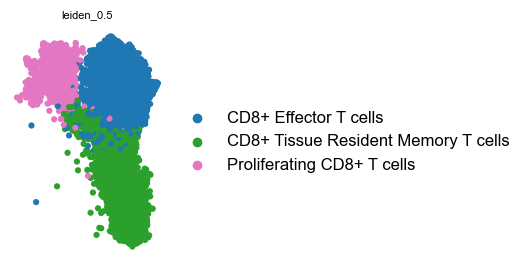

In [242]:

plt.rcParams.update({'font.size': 16}) 
#sc.settings.figdir = '/burg/iicd_new/users/ls3456/GVHD/Figures/Trajectory_figures/'
plt.figure(figsize=(15, 6))
# Now the plot will be saved in the specified directory
sc.pl.umap(tcell_ann_concat_Mobile_conv[np.random.permutation(len(tcell_ann_concat_Mobile_conv))],
    color=['leiden_0.5'],
    show=False,  # Do not show the plot yet,
    frameon=False,
    size=80,
    legend_loc= 'right margin',
    legend_fontsize = 12)

# Save the figure at 300 DPI
plt.savefig("//Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/leiden_Mobile_conv_umap.png", dpi=300,bbox_inches='tight')
plt.savefig("/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/leiden_Mobile_conv_umap.pdf", dpi=300,bbox_inches='tight')

In [243]:

### TO do  review change resi code
import plotly.graph_objects as go
link_colors = [
    'rgba(31, 119, 180, 0.3)',  # Blue for 'Infiltrating activated cytotoxic T-cells'
    'rgba(31, 119, 180, 0.3)',  # Blue
    'rgba(31, 119, 180, 0.3)',  # Blue
    'rgba(44, 160, 44, 0.3)',   # Green for 'Resident CD8+ T-cells'
    'rgba(44, 160, 44, 0.3)',   # Green
    'rgba(44, 160, 44, 0.3)',   # Green
    'rgba(227, 119, 194, 0.3)', # Pink for 'Proliferating CD8+ T-cells'
    'rgba(227, 119, 194, 0.3)', # Pink
    'rgba(227, 119, 194, 0.3)'  # Pink
]

Change_State_Resi = []
activated_state = pd.DataFrame()
proliferating_state = pd.DataFrame()
resident_state = pd.DataFrame()
for i in tcell_ann_concat_Mobile_conv.obs['GVHD_Grade_1'].unique():
    print(i)
    tcr_dataset = tcell_ann_concat_Mobile_conv[tcell_ann_concat_Mobile_conv.obs['GVHD_Grade_1'] == i]
    df= pd.DataFrame()
    df_before =pd.DataFrame()
    for t_cell_states in tcell_ann_concat_Mobile_conv.obs['leiden_0.5'].unique():
        print(t_cell_states)
        adata = tcr_dataset[tcr_dataset.obs['leiden_0.5'] == t_cell_states]
        adata_lp = adata[adata.obs['LPorIE'] == 'Lamina Propria Cells']
        adata_ie = tcr_dataset[tcr_dataset.obs['LPorIE'] == 'Intraepithelial Cells']
        adata_migrate = adata_ie[adata_ie.obs['cc_aa_alignment_same_v_Grade'].isin(adata_lp.obs['cc_aa_alignment_same_v_Grade'])]
        print(len(adata_migrate))
        
        adata_migrate.obs['leiden_0.5'] = pd.Categorical(adata_migrate.obs['leiden_0.5'], categories=['CD8+ Tissue Resident Memory T cells','CD8+ Effector T cells','Proliferating CD8+ T cells'])
        adata_ie_resident = adata_ie[adata_ie.obs['leiden_0.5'] == 'CD8+ Tissue Resident Memory T cells']
        adata_ie_resident_migrated_lp = adata_lp[adata_lp.obs['cc_aa_alignment_same_v_Grade'].isin(adata_ie_resident.obs['cc_aa_alignment_same_v_Grade'])]
        adata_ie_resident_migrated_lp_not_resident = adata_ie_resident_migrated_lp[adata_ie_resident_migrated_lp.obs['leiden_0.5'] != 'Resident CD8+ T-cells']
        adata_ie_resident_change = adata_ie_resident[adata_ie_resident.obs['cc_aa_alignment_same_v_Grade'].isin(adata_ie_resident_migrated_lp_not_resident.obs['cc_aa_alignment_same_v_Grade'])]

        print(adata_ie_resident_change.obs.index)
        Change_State_Resi.append(list(adata_ie_resident_change.obs.index))
        df[t_cell_states] = adata_migrate.obs['leiden_0.5'].value_counts(normalize=True)
        print(adata_migrate.obs['leiden_0.5'].unique())

    print(df)
    activated_state[i] = df['CD8+ Effector T cells']
    proliferating_state[i] = df['Proliferating CD8+ T cells']
    resident_state[i] = df['CD8+ Tissue Resident Memory T cells']
    df.fillna(0, inplace=True)

Severe
CD8+ Effector T cells
1817
Index(['AAAGATGGTACTTGAC-1', 'ACACTGAGTGCTCTTC-1', 'ACCTTTATCCCTGACT-1',
       'ACGAGCCAGCCACGCT-1', 'ACGGGCTAGGATGTAT-1', 'AGAGTGGAGCCTCGTG-1',
       'AGGCCGTCATAAGACA-1', 'AGGGTGAGTAGAAAGG-1', 'ATAGACCCACCTGGTG-1',
       'CACATAGTCACGCATA-1',
       ...
       'TTCTCAAAGGCTCAGA-1', 'TTCTTAGTCACCGTAA-1', 'TTGACTTAGGGTATCG-1',
       'TTGACTTCAATGCCAT-1', 'TTGGAACTCCACTCCA-1', 'TTGGAACTCGAACTGT-1',
       'TTGGCAACAGACAAAT-1', 'TTGGCAACAGACGCTC-1', 'TTTACTGAGTCTCCTC-1',
       'TTTGGTTGTGCATCTA-1'],
      dtype='object', length=749)
['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells', 'Proliferating CD8+ T cells']
Categories (3, object): ['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells', 'Proliferating CD8+ T cells']
CD8+ Tissue Resident Memory T cells


/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3590447686.py:32: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3590447686.py:32: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



1126
Index(['AAAGATGGTACTTGAC-1', 'ACACTGAGTGCTCTTC-1', 'ACCTTTATCCCTGACT-1',
       'ACGAGCCAGCCACGCT-1', 'ACGGGCTAGGATGTAT-1', 'ACTTGTTAGCCTCGTG-1',
       'AGAGTGGAGCCTCGTG-1', 'AGGCCGTCATAAGACA-1', 'AGGGAGTAGTACGTAA-1',
       'AGGGTGAGTAGAAAGG-1',
       ...
       'TTCTTAGTCACCGTAA-1', 'TTGACTTAGGGTATCG-1', 'TTGACTTCAATGCCAT-1',
       'TTGGAACTCCACTCCA-1', 'TTGGAACTCGAACTGT-1', 'TTGGCAACAGACAAAT-1',
       'TTGGCAACAGACGCTC-1', 'TTTACTGAGTCTCCTC-1', 'TTTGGTTGTCTAGAGG-1',
       'TTTGGTTGTGCATCTA-1'],
      dtype='object', length=843)
['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells', 'Proliferating CD8+ T cells']
Categories (3, object): ['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells', 'Proliferating CD8+ T cells']
Proliferating CD8+ T cells
1304


/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3590447686.py:32: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3590447686.py:32: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



Index(['AAAGATGGTACTTGAC-1', 'ACCTTTATCCCTGACT-1', 'ACGAGCCAGCCACGCT-1',
       'ATAGACCCACCTGGTG-1', 'CACCTTGCACGGCTAC-1', 'CATCCACCAGCCAGAA-1',
       'CGTGTAATCGTGGTCG-1', 'GAGCAGAAGAGTACAT-1', 'GGTGAAGGTATGGTTC-1',
       'GTCGTAAAGAACAACT-1',
       ...
       'TGTGGTACACCGAATT-1', 'TGTTCCGTCTCGATGA-1', 'TTCCCAGAGTCCCACG-1',
       'TTCGAAGCAGTATGCT-1', 'TTCGGTCGTAGCGTAG-1', 'TTCTCAAAGGCTCAGA-1',
       'TTCTTAGTCACCGTAA-1', 'TTGACTTCAATGCCAT-1', 'TTGGAACTCCACTCCA-1',
       'TTTACTGAGTCTCCTC-1'],
      dtype='object', length=589)
['CD8+ Tissue Resident Memory T cells', 'Proliferating CD8+ T cells', 'CD8+ Effector T cells']
Categories (3, object): ['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells', 'Proliferating CD8+ T cells']
                                     CD8+ Effector T cells  \
leiden_0.5                                                   
CD8+ Effector T cells                             0.461200   
CD8+ Tissue Resident Memory T cells               0.412218

...

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3590447686.py:32: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3590447686.py:32: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



Index(['AACTCAGGTAAGCACG-1', 'ACGGAGAAGCTGAAAT-1', 'ACGGGTCGTAGCGTGA-1',
       'ACGTCAAAGATGCCTT-1', 'ACTGATGAGGATGGAA-1', 'ACTTGTTTCTGTCAAG-1',
       'AGGGTGAGTGGTACAG-1', 'ATCGAGTAGGACAGAA-1', 'ATGAGGGGTAAGAGGA-1',
       'ATGCGATAGCGTTTAC-1', 'CATGGCGTCCAGAAGG-1', 'CCTAAAGGTTTAAGCC-1',
       'CCTAGCTAGCAGCGTA-1', 'CGCGTTTAGCGTAATA-1', 'CGGGTCAAGCTCCCAG-1',
       'CGTAGCGAGGCTAGGT-1', 'CGTCACTCACGCGAAA-1', 'CGTCACTGTACTCTCC-1',
       'CGTCACTGTAGAGTGC-1', 'CTGCTGTCAGATCTGT-1', 'CTGGTCTTCGCACTCT-1',
       'GAACGGACATGCCTAA-1', 'GCATGATGTAAATGTG-1', 'GCGACCAAGAAGGCCT-1',
       'GGAATAATCACAATGC-1', 'GGGAGATGTAGAAGGA-1', 'GTACTCCTCAAGAAGT-1',
       'GTAGGCCCAGGACGTA-1', 'GTCTCGTAGTAATCCC-1', 'GTTCGGGCAATAACGA-1',
       'TAAGCGTGTACTCTCC-1', 'TATGCCCGTAGCTGCC-1', 'TCAATCTAGGGTGTGT-1',
       'TCAGGATGTTACCGAT-1', 'TCGAGGCAGACAGACC-1', 'TCGCGTTAGATCCCAT-1',
       'TCTCTAATCCCATTAT-1', 'TGCCCATCACGACTCG-1', 'TGGTTAGTCGGAATCT-1',
       'TGTGTTTAGTTCGCGC-1', 'TTAGTTCCACTCGACG-1', 

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3590447686.py:32: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3590447686.py:32: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



Index(['AAACCTGAGTTACCCA-1', 'AAACCTGTCCGCTGTT-1', 'AAAGCAATCTACCTGC-1',
       'AACCATGCAATCCAAC-1', 'AACCATGGTACTCTCC-1', 'AACCATGTCCTACAGA-1',
       'AACCGCGGTCAGAATA-1', 'AACTCCCGTTTAGCTG-1', 'AACTTTCGTGGAAAGA-1',
       'AACTTTCTCGCGTAGC-1',
       ...
       'ATCATGGCAACGATCT-1', 'CACCAGGTCGCAAACT-1', 'GAGGTGAGTGGTAACG-1',
       'GCGCAGTGTACTTAGC-1', 'GGCGACTCAGGAATCG-1', 'GTTCGGGAGTACGCGA-1',
       'TGCTGCTTCCCACTTG-1', 'TGGGAAGAGCCACTAT-1', 'TTCTCCTTCAATCACG-1',
       'TTGACTTAGGTAAACT-1'],
      dtype='object', length=506)
['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells', 'Proliferating CD8+ T cells']
Categories (3, object): ['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells', 'Proliferating CD8+ T cells']
Proliferating CD8+ T cells
2
Index([], dtype='object')
['Proliferating CD8+ T cells']
Categories (3, object): ['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells', 'Proliferating CD8+ T cells']
                                     CD

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3590447686.py:32: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



In [244]:
#sc.pl.umap(tcell_ann_concat_Mobile, color='leiden_LPorIE')
# plot clones on decipher trajectory

tcell_ann_concat_Mobile.obs['Change_Resi'] = 'No'

tcell_ann_concat_Mobile.obs.loc[tcell_ann_concat_Mobile.obs.index.isin(Change_State_Resi[1]),'Change_Resi'] = "Yes"

#sc.pl.umap(tcell_ann_concat_Mobile, color='Change_Resi')
# plot clones on decipher trajectory

#sc.pl.umap(tcell_ann_concat_Mobile[tcell_ann_concat_Mobile.obs['leiden_0.5'] == 'CD8+ Tissue Resident Memory T cells'], color='Change_Resi')
# plot clones on decipher trajectory

Change_Resi = tcell_ann_concat_Mobile[tcell_ann_concat_Mobile.obs['leiden_0.5'] == 'CD8+ Tissue Resident Memory T cells']

#sc.pl.umap(Change_Resi, color=['leiden_0.5','Change_Resi','IL7R','GVHD_Grade_1'])

In [245]:
list(tcell_ann_concat_Mobile.obs['leiden_0.5'].unique())

['CD8+ Effector T cells',
 'CD8+ Tissue Resident Memory T cells',
 'CD4+ Central Memory T cells',
 'Proliferating CD8+ T cells',
 'Low CD3',
 'CD4+ Regulatory T cells',
 'CD4+ Effector T cells',
 'CD8+ Cytotoxic Unconventional T cells',
 'CD8+ Homeostatic Unconventional T cells']

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1185338541.py:13: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



['CD8+ Tissue Resident Memory T cells', 'Proliferating CD8+ T cells', 'CD8+ Effector T cells']
0
9668_Severe_C66_Upper GI_0.0


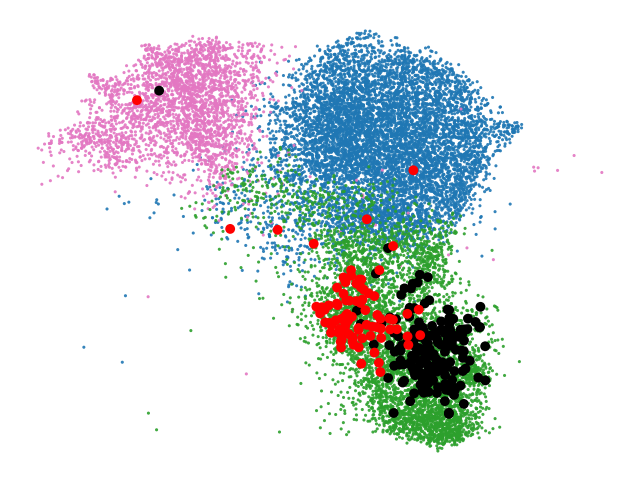

['CD8+ Tissue Resident Memory T cells']
1
5317_ND_ND001_Upper GI_nan


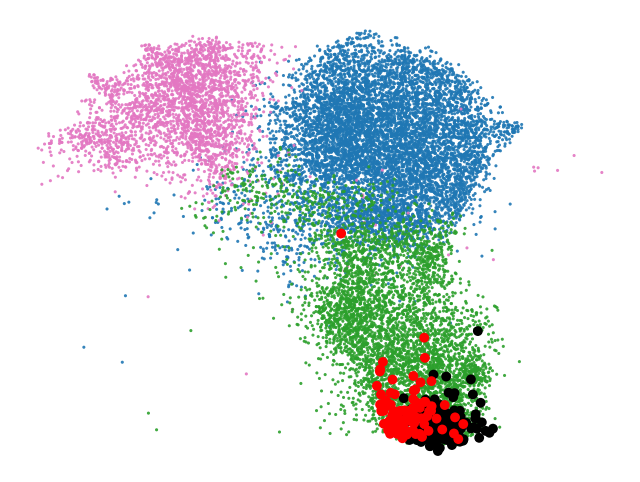

['Proliferating CD8+ T cells', 'CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells']
2
3839_Severe_C068_Upper GI_11.0


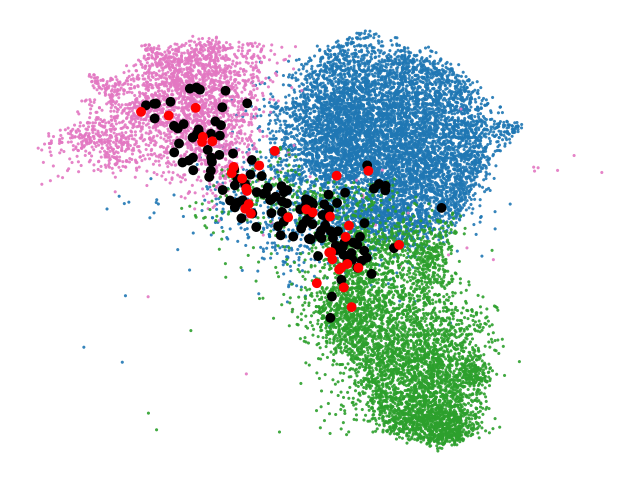

['CD8+ Tissue Resident Memory T cells']
3
7814_No_R085_Upper GI_-88.0


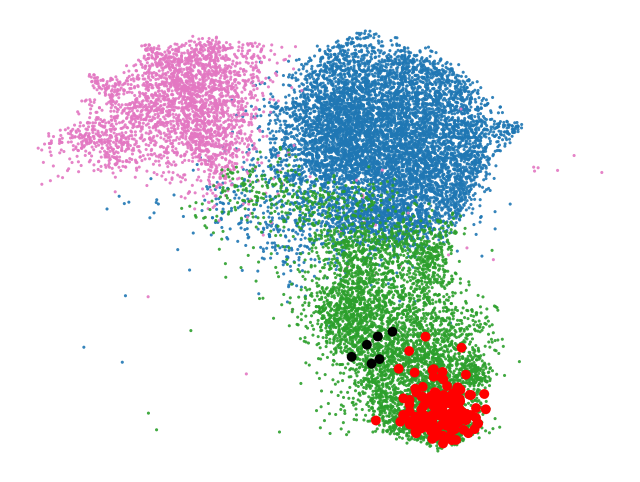

['Proliferating CD8+ T cells', 'CD8+ Effector T cells', 'CD8+ Tissue Resident Memory T cells']
4
6644_Severe_C98_Upper GI_84.0


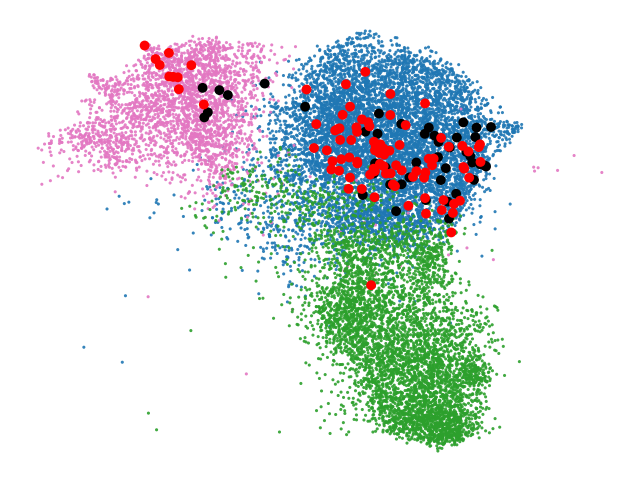

['CD8+ Effector T cells', 'CD8+ Tissue Resident Memory T cells', 'Proliferating CD8+ T cells']
5
6630_Severe_C98_Upper GI_84.0


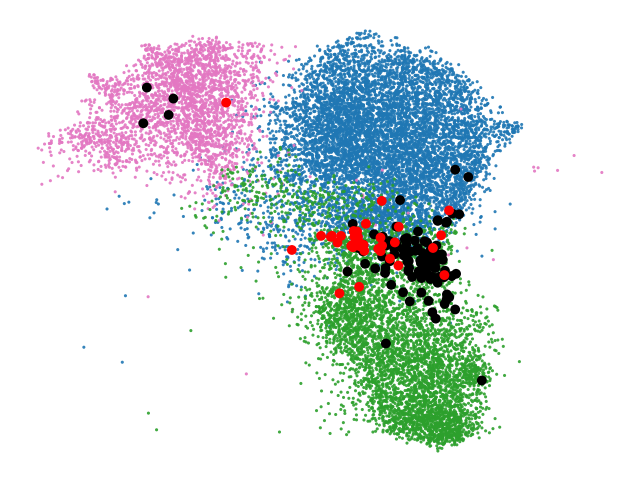

['CD8+ Tissue Resident Memory T cells', 'Proliferating CD8+ T cells']
6
5033_Mild_C157_Upper GI_0.0


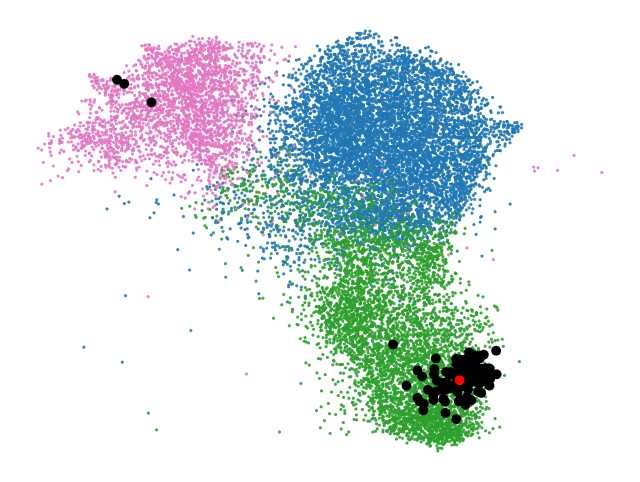

['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells', 'Proliferating CD8+ T cells']
7
6627_Severe_C98_Upper GI_84.0


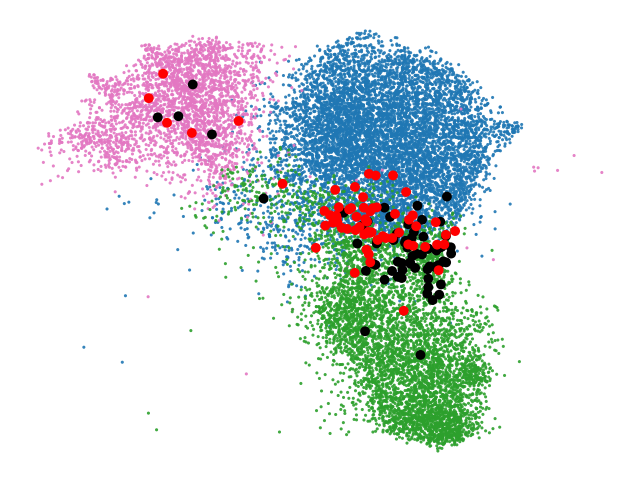

['CD8+ Tissue Resident Memory T cells', 'Proliferating CD8+ T cells', 'CD8+ Effector T cells']
8
5049_Severe_C66_Upper GI_0.0


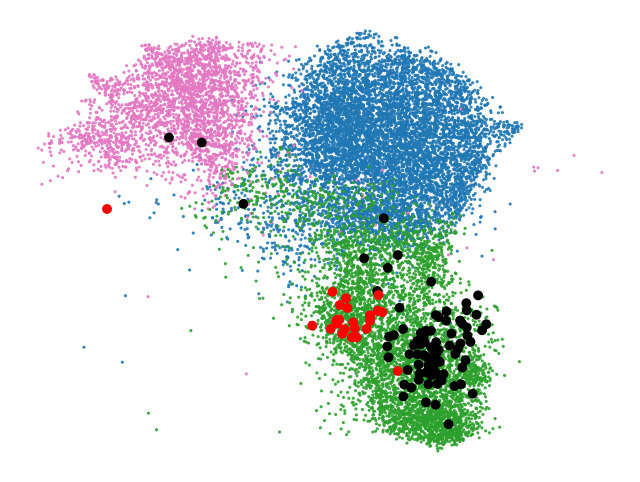

['CD8+ Effector T cells', 'Proliferating CD8+ T cells']
9
9675_Severe_C66_Upper GI_0.0


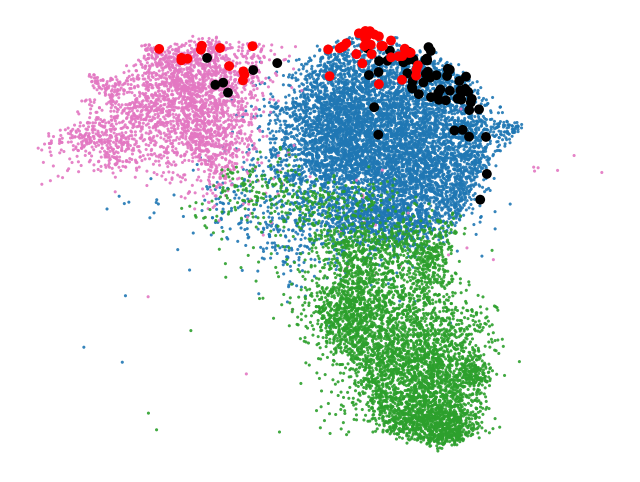

['CD8+ Effector T cells', 'Proliferating CD8+ T cells']
10
6629_Severe_C98_Upper GI_84.0


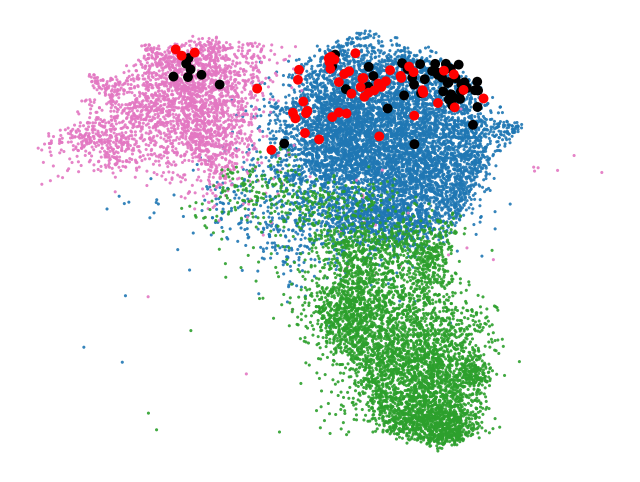

['CD8+ Tissue Resident Memory T cells']
11
7812_No_R085_Upper GI_-88.0


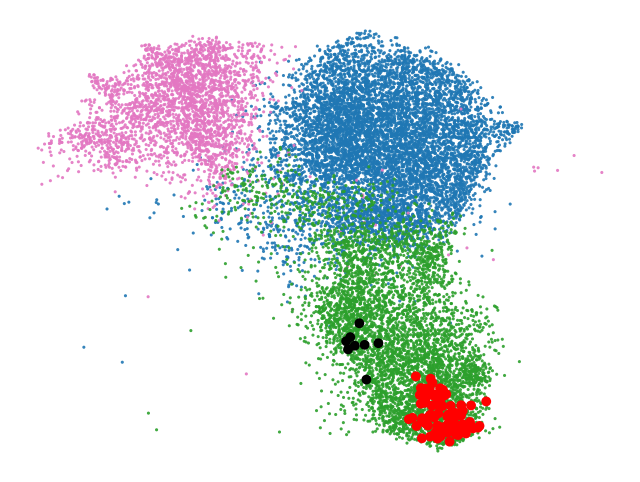

['CD8+ Tissue Resident Memory T cells', 'CD8+ Effector T cells']
12
9676_Severe_C66_Upper GI_0.0


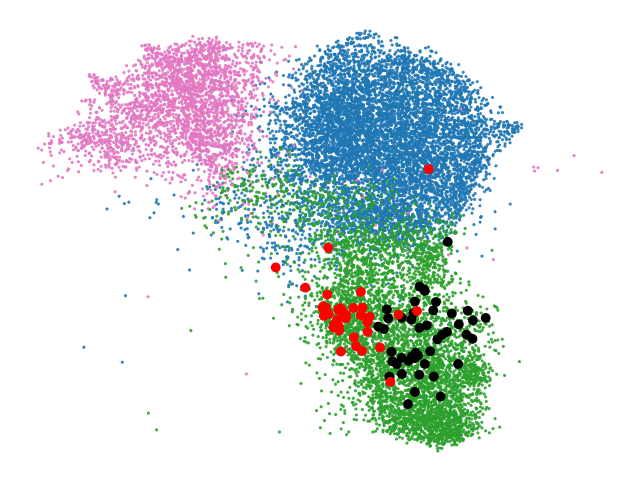

['Proliferating CD8+ T cells', 'CD8+ Tissue Resident Memory T cells']
13
5058_Mild_C157_Upper GI_0.0


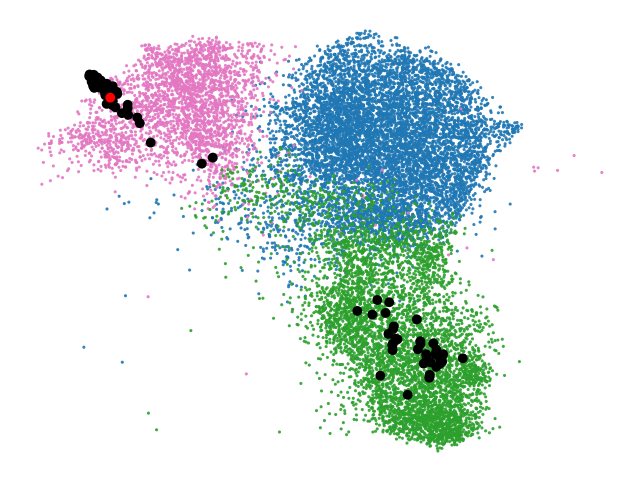

['CD8+ Effector T cells', 'CD8+ Tissue Resident Memory T cells', 'Proliferating CD8+ T cells']
14
6647_Severe_C98_Upper GI_84.0


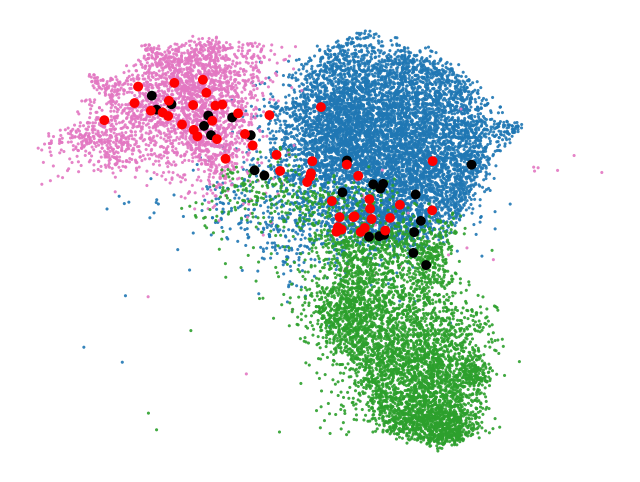

In [246]:
# Step 1: Add IE and LP colors to the provided color map for CD8 T-cell types
cd8_colors = {
    'CD8+ Effector T cells': '#1f77b4',
    'Proliferating CD8+ T cells': '#e377c2',
    'CD8+ Tissue Resident Memory T cells': '#2ca02c',
    #'CD8+ Cytotoxic Unconventional T cells': '#9467bd',
    #'CD8+ Homeostatic Unconventional T cells': '#bcbd22',
    'Intraepithelial Cells': 'black',  # Custom color for IE
    'Lamina Propria Cells': 'red'    # Custom color for LP
}

tcell_ann_concat_Mobile.obs['cc_aa_alignment_same_v_Grade'] = tcell_ann_concat_Mobile.obs['cc_aa_alignment_same_v'].astype(str)+'_'+tcell_ann_concat_Mobile.obs['GVHD_Grade_1'].astype(str)+'_'+tcell_ann_concat_Mobile.obs['PatientID'].astype(str)+'_'+tcell_ann_concat_Mobile.obs['Tissue_Location'].astype(str)+'_'+tcell_ann_concat_Mobile.obs['Dates_from_Transplantation'].astype(str)
Change_Resi.obs['cc_aa_alignment_same_v_Grade'] = Change_Resi.obs['cc_aa_alignment_same_v'].astype(str)+'_'+Change_Resi.obs['GVHD_Grade_1'].astype(str)+'_'+Change_Resi.obs['PatientID'].astype(str)+'_'+Change_Resi.obs['Tissue_Location'].astype(str)+'_'+Change_Resi.obs['Dates_from_Transplantation'].astype(str)

Change_Resi_real = tcell_ann_concat_Mobile[tcell_ann_concat_Mobile.obs['Change_Resi']== 'Yes']
# Step 1: Filter for Proliferating CD8+ T-cells
prolif_cd8_data = tcell_ann_concat_Mobile_conv[tcell_ann_concat_Mobile_conv.obs['cc_aa_alignment_same_v'].isin(Change_Resi_real.obs['cc_aa_alignment_same_v'])]

clone_counts = tcell_ann_concat_Mobile_conv.obs.groupby('cc_aa_alignment_same_v_Grade').size()

# Step 3: Get the top 10 clones by counts
top_10_clones = clone_counts.nlargest(15).index

# Step 4: Loop through each of the top clones and create individual plots
for i, value in enumerate(top_10_clones):
    # Create a new figure for each plot
    plt.figure(figsize=(8, 6))

    # Plot all cells colored by their corresponding cell types from cd8_colors
    
    for cell_type, color in cd8_colors.items():
        cell_data = tcell_ann_concat[tcell_ann_concat.obs['leiden_0.5'] == cell_type]
        plt.scatter(cell_data.obsm['X_umap'][:, 0], cell_data.obsm['X_umap'][:, 1],
                    c=color, s=5, alpha=0.9, label=cell_type, edgecolor = "none", marker='o')

    # Subset the data for the current clone
    clone_data = tcell_ann_concat_Mobile_conv[tcell_ann_concat_Mobile_conv.obs['cc_aa_alignment_same_v_Grade'] == value]
    print(list(clone_data.obs['leiden_0.5'].unique()))

    # Map 'LPorIE' values to colors using the cd8_colors map
    clone_colors = clone_data.obs['LPorIE'].map(cd8_colors)

    # Plot the current clone with a color map based on LPorIE (Intraepithelial or Lamina Propria)
    scatter = plt.scatter(clone_data.obsm['X_umap'][:, 0], clone_data.obsm['X_umap'][:, 1],
                          c=clone_colors, s=50, alpha=1, label=f'Clone {value}', edgecolor = "none", marker='o')

    # Adding colorbar, labels, and title
    #plt.title(f'Clone {value} ')
    plt.gca().set_axis_off()
    
    # plt.xlabel('Decipher Component 1')
    # plt.ylabel('Decipher Component 2')

    # Add legend
    #plt.legend(loc='upper right', bbox_to_anchor=(2, 1))
    print(i)
    print(value)

    # Show the plot for the current clone
    
            # Save figure with 300 DPI
    plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/fig_{value}_umap_300dpi.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/fig_{value}_umap_300dpi.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/fig_{value}_umap_300dpi.svg', dpi=300, bbox_inches='tight')
    plt.show()

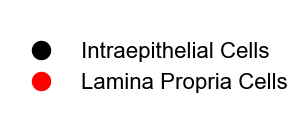

In [247]:
# Create a new figure just for the legend
plt.figure(figsize=(3, 1.5))

# Create legend handles with circular markers
from matplotlib.lines import Line2D

ie_marker = Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                  markersize=15, label='Intraepithelial Cells')
lp_marker = Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                  markersize=15, label='Lamina Propria Cells')

# Add the legend
plt.legend(handles=[ie_marker, lp_marker], loc='center', frameon=False)

# Remove the axes
plt.gca().set_axis_off()

# Save the legend as a separate file
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/legend_IE_LP.png', dpi=300, bbox_inches='tight')
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/legend_IE_LP.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/legend_IE_LP.svg', dpi=300, bbox_inches='tight')

plt.show()

In [248]:
Resi = tcell_ann_concat_Mobile[tcell_ann_concat_Mobile.obs['leiden_0.5'] == 'CD8+ Tissue Resident Memory T cells']

In [249]:
# Compute the nearest neighbors
sc.pp.neighbors(Resi,use_rep="X_scVI")

# Run Leiden clustering
#sc.tl.leiden(Resi, resolution=0.09)  # You can adjust the resolution for more/less clusters
sc.tl.leiden(Resi, resolution=0.09)  # You can adjust the resolution for more/less clusters

In [250]:
#Change_Resi[Change_Resi.obs['Change_Resi']=='Yes']

In [251]:
#Resi[Resi.obs['leiden']=='1']

In [252]:
# Define the order you want
desired_order = ['ND','No', 'Mild', 'Severe']  # Adjust based on your data

# Convert to categorical with specified order
Resi.obs["GVHD_Grade_1"] = pd.Categorical(
    Resi.obs["GVHD_Grade_1"],
    categories=desired_order,
    ordered=True
)
Resi.uns["GVHD_Grade_1_colors"] = ['#7A1E76','#09BB8C','#005A8F', '#B85000']

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3577302296.py:27: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



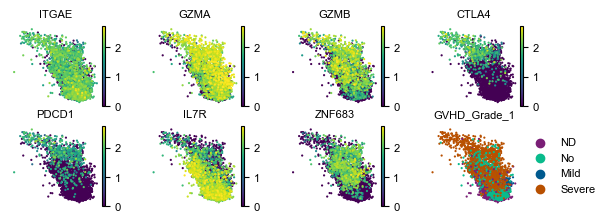

In [253]:
import matplotlib as mpl
mpl.rcParams['image.cmap'] = 'viridis'  # Or your preferred colormap
mpl.rcParams.update({'font.size': 8,
                    'svg.fonttype': 'none'})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size


fig = sc.pl.umap(
    Resi,
    color=['ITGAE','GZMA','GZMB','CTLA4','PDCD1','IL7R','ZNF683',"GVHD_Grade_1"],
    show=False,  # Do not show the plot yet
    frameon=False,
    #size=80,
    vmin=0,  # Set the minimum value for the IL7R color scale
    vmax=2.75,
    #legend_loc=None,  # Remove legend
    title=None,       # Remove title
    return_fig = True,
    s = 10
)
# Access the current Axes and update the title font size

fig.set_size_inches(6.5, 2.2)

plt.tight_layout()

# Save the figure at 300 DPI
fig.savefig("/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/leiden_il7_grade_umap.png", dpi=300, transparent=True)
fig.savefig("/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/leiden_il7_grade_umap.pdf", dpi=300, transparent=True)
fig.savefig("/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/leiden_il7_grade_umap.svg", dpi=300, transparent=True)
# Optionally, show the plot after saving
plt.show()

In [254]:
tcell_ann_concat_Mobile.obs['leiden_new_cluster_2'] =tcell_ann_concat_Mobile.obs['leiden_0.5']
tcell_ann_concat_Mobile.obs['leiden_new_cluster_2'] = tcell_ann_concat_Mobile.obs['leiden_new_cluster_2'].cat.add_categories(['CD8+ Transitioning Resident T cells'])
tcell_ann_concat_Mobile.obs.loc[tcell_ann_concat_Mobile.obs.index.isin(Resi[Resi.obs['leiden']=='1'].obs.index),'leiden_new_cluster_2'] = 'CD8+ Transitioning Resident T cells'



tcell_ann_concat_Mobile_conv = tcell_ann_concat_Mobile[tcell_ann_concat_Mobile.obs['leiden_0.5'].isin(['CD8+ Tissue Resident Memory T cells','CD8+ Effector T cells','Proliferating CD8+ T cells'] )]
tcell_ann_concat_Mobile_conv.obs['cc_aa_alignment_same_v_Grade'] = tcell_ann_concat_Mobile_conv.obs['cc_aa_alignment_same_v'].astype(str)+'_'+tcell_ann_concat_Mobile_conv.obs['GVHD_Grade_1'].astype(str)+'_'+tcell_ann_concat_Mobile_conv.obs['PatientID'].astype(str)+'_'+tcell_ann_concat_Mobile_conv.obs['Tissue_Location'].astype(str)+'_'+tcell_ann_concat_Mobile_conv.obs['Dates_from_Transplantation'].astype(str)

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/2038666382.py:8: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



In [255]:
tcell_ann_concat.obs['leiden_new_cluster_2'] =tcell_ann_concat.obs['leiden_0.5']
tcell_ann_concat.obs['leiden_new_cluster_2'] = tcell_ann_concat.obs['leiden_new_cluster_2'].cat.add_categories(['CD8+ Transitioning Resident T cells'])
tcell_ann_concat.obs.loc[tcell_ann_concat.obs.index.isin(Resi[Resi.obs['leiden']=='1'].obs.index),'leiden_new_cluster_2'] = 'CD8+ Transitioning Resident T cells'

In [256]:
existing_colors = tcell_ann_concat_Mobile_conv.uns['leiden_0.5_colors']

In [257]:
existing_colors

array(['#1f77b4', '#2ca02c', '#e377c2'], dtype=object)

In [258]:
tcell_ann_concat_Mobile_conv.obs['leiden_0.5']

AAAGCAAAGAGGTACC-1                  CD8+ Effector T cells
AACGTTGAGGCACATG-1    CD8+ Tissue Resident Memory T cells
AATCGGTGTCATACTG-1    CD8+ Tissue Resident Memory T cells
ACATACGAGATAGCAT-1                  CD8+ Effector T cells
ACGGAGACATGTAAGA-1                  CD8+ Effector T cells
                                     ...                 
CGACCTTGTTTGACAC-1    CD8+ Tissue Resident Memory T cells
GACGTGCTCCAGTATG-1    CD8+ Tissue Resident Memory T cells
GTAACGTTCGCTTAGA-1    CD8+ Tissue Resident Memory T cells
GTGTTAGAGACACTAA-1    CD8+ Tissue Resident Memory T cells
TGTGTTTAGATAGTCA-1    CD8+ Tissue Resident Memory T cells
Name: leiden_0.5, Length: 6413, dtype: category
Categories (3, object): ['CD8+ Effector T cells', 'CD8+ Tissue Resident Memory T cells', 'Proliferating CD8+ T cells']

In [259]:
tcell_ann_concat_Mobile_conv.obs['leiden_new_cluster_2']

AAAGCAAAGAGGTACC-1                  CD8+ Effector T cells
AACGTTGAGGCACATG-1    CD8+ Tissue Resident Memory T cells
AATCGGTGTCATACTG-1    CD8+ Tissue Resident Memory T cells
ACATACGAGATAGCAT-1                  CD8+ Effector T cells
ACGGAGACATGTAAGA-1                  CD8+ Effector T cells
                                     ...                 
CGACCTTGTTTGACAC-1    CD8+ Tissue Resident Memory T cells
GACGTGCTCCAGTATG-1    CD8+ Tissue Resident Memory T cells
GTAACGTTCGCTTAGA-1    CD8+ Tissue Resident Memory T cells
GTGTTAGAGACACTAA-1    CD8+ Tissue Resident Memory T cells
TGTGTTTAGATAGTCA-1    CD8+ Tissue Resident Memory T cells
Name: leiden_new_cluster_2, Length: 6413, dtype: category
Categories (4, object): ['CD8+ Effector T cells', 'CD8+ Tissue Resident Memory T cells', 'Proliferating CD8+ T cells', 'CD8+ Transitioning Resident T cells']

In [260]:
# Define a color for the new cluster (e.g., '#ff7f0e' for orange)
new_cluster_color = '#FFA500'

# Create the updated list of colors by appending the new color
updated_colors = ['#1f77b4','#2ca02c','#e377c2','#FFA500',]


In [261]:
# Set the color map for leiden_new_cluster_2
tcell_ann_concat_Mobile_conv.uns['leiden_new_cluster_2_colors'] = updated_colors
#tcell_ann_concat_Mobile_conv.uns['leiden_new_cluster_colors'] = updated_colors

In [262]:
#tcell_ann_concat_Mobile_conv[np.random.permutation(len(tcell_ann_concat_Mobile_conv))]

/Users/lingting/ENTER/envs/mrvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/lingting/ENTER/envs/mrvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/lingting/ENTER/envs/mrvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



<Figure size 1500x600 with 0 Axes>

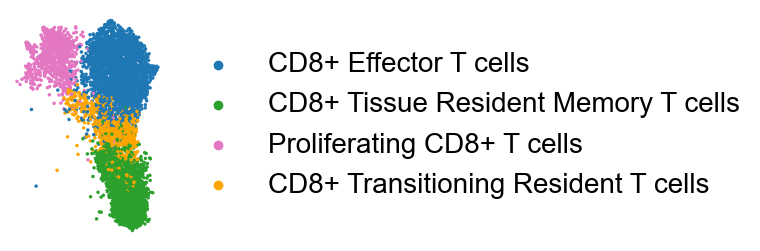

In [263]:

#sc.settings.figdir = '/burg/iicd_new/users/ls3456/GVHD/Figures/Trajectory_figures/'
plt.figure(figsize=(15, 6))
# Now the plot will be saved in the specified directory
sc.pl.umap(tcell_ann_concat_Mobile_conv[np.random.permutation(len(tcell_ann_concat_Mobile_conv))],
    color=['leiden_new_cluster_2'],
    show=False,  # Do not show the plot yet,
    frameon=False,
    size=25,
    legend_loc= 'right margin',
    legend_fontsize = 20)

plt.gca().set_title('')

# Save the figure at 300 DPI
plt.savefig("/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/leiden_Change_Resi_umap.png", dpi=300,bbox_inches='tight')
plt.savefig("/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/leiden_Change_Resi_umap.svg", dpi=300,bbox_inches='tight')
plt.savefig("/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/leiden_Change_Resi_umap.pdf", dpi=300,bbox_inches='tight')

In [264]:
tcell_ann_concat_Mobile_conv

AnnData object with n_obs × n_vars = 6413 × 38012
    obs: 'PatientID', 'SampleID', 'FreshorFrozen', 'Days_post-Transplant', 'Tissue_Location', 'LPorIE', 'Enrichment Method', 'Pathological_grade_of_GVHD', 'Pathological_grade_of_GVHD_num', 'Grade_num', 'GVHD_Grade_1', 'GVHD_Grade_2', 'GVHD_Grade_3', 'Transplant_Conditioning', 'Gender', 'Time_1stGVHD', 'Donor', 'Disease', 'GVHD_Prophylaxis_Regimen', 'Dates_from_Transplantation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'is_doublet', 'leiden', 'leiden_old', 'leiden_0.15', 'predicted_labels', 'cellType_General markers of T cells_markers', 'cellType_Terminal\nexhaustion_markers', 'cellType_Precursor\nexhaustion_markers', 'cellType_Stem_markers', 'cellType_Transitory T cells_markers', 'cellType_Activated T cells_markers', 'cellType_Naïve T cells_markers', 'cellType_Stem cell Memory T cells_markers', 'cellType_Central Memory T cells_markers', 'cellType_Effector Memory T cells_markers', 'cellTyp

In [265]:
from matplotlib import rcParams
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator  # Assuming you use statannotations for the p-values
from copy import deepcopy

In [266]:
import plotly.graph_objects as go
from anndata import AnnData
### Remove them

link_colors = [
    'rgba(31, 119, 180, 0.3)',  # Blue for 'Infiltrating activated cytotoxic T-cells'
    'rgba(31, 119, 180, 0.3)',  # Blue
    'rgba(31, 119, 180, 0.3)',  # Blue
    'rgba(31, 119, 180, 0.3)',  # Blue
    'rgba(255, 165, 0, 0.3)',
    'rgba(255, 165, 0, 0.3)',
    'rgba(255, 165, 0, 0.3)',
    'rgba(255, 165, 0, 0.3)',
    'rgba(44, 160, 44, 0.3)',   # Green for 'Resident CD8+ T-cells'
    'rgba(44, 160, 44, 0.3)',   # Green
    'rgba(44, 160, 44, 0.3)',   # Green
    'rgba(44, 160, 44, 0.3)',   # Green
    'rgba(227, 119, 194, 0.3)', # Pink for 'Proliferating CD8+ T-cells'
    'rgba(227, 119, 194, 0.3)', # Pink
    'rgba(227, 119, 194, 0.3)',  # Pink
    'rgba(227, 119, 194, 0.3)'  # Pink
]

for i in tcell_ann_concat_Mobile_conv.obs['GVHD_Grade_1'].unique():
    print(i)
    tcr_dataset = tcell_ann_concat_Mobile_conv[tcell_ann_concat_Mobile_conv.obs['GVHD_Grade_1'] == i]
    # Create a pivot table with 'PatientID' as rows, 'Treatment' as columns, and the mean of 'GeneExpression'
    obs_df = tcr_dataset.obs 
    pivot_table = pd.pivot_table(obs_df, values='cc_aa_alignment_same_v_Grade', index='leiden_new_cluster_2', columns='LPorIE', aggfunc='count')
    normalized_pivot_table = pivot_table.div(pivot_table.sum(axis=0), axis=1)
    print(normalized_pivot_table)
    
    df= pd.DataFrame()
    df_before =pd.DataFrame()
    total_migrate_count = 0
    total_lp_count = 0
    accumulated_adata_migrate = []
    accumulated_adata_lp_count = []
    for t_cell_states in tcell_ann_concat_Mobile_conv.obs['leiden_new_cluster_2'].unique():
        print(t_cell_states)
        adata = tcr_dataset[tcr_dataset.obs['leiden_new_cluster_2'] == t_cell_states]
        adata_lp = adata[adata.obs['LPorIE'] == 'Lamina Propria Cells']
        adata_ie = tcr_dataset[tcr_dataset.obs['LPorIE'] == 'Intraepithelial Cells']
        adata_migrate = adata_ie[adata_ie.obs['cc_aa_alignment_same_v_Grade'].isin(adata_lp.obs['cc_aa_alignment_same_v_Grade'])]
        adata_lp_count= adata_lp[adata_lp.obs['cc_aa_alignment_same_v_Grade'].isin(adata_migrate.obs['cc_aa_alignment_same_v_Grade'])]
        adata_ie_count= adata_ie[adata_ie.obs['cc_aa_alignment_same_v_Grade'].isin(adata_migrate.obs['cc_aa_alignment_same_v_Grade'])]
        
        total_migrate_count += len(adata_migrate)
        total_lp_count += len(adata_lp_count)
        
        #print("adata_migrate count:",len(adata_migrate))
        #print("adata_lp count:",len(adata_lp_count))
        #print("adata_ie count:",len(adata_ie_count))
        
        # Concatenate the new data to the accumulated data
        accumulated_adata_migrate = accumulated_adata_migrate+list(adata_migrate.obs.index)
        accumulated_adata_lp_count = accumulated_adata_lp_count+list(adata_lp_count.obs.index)
        
        adata_migrate.obs['leiden_new_cluster_2'] = pd.Categorical(adata_migrate.obs['leiden_new_cluster_2'], categories=['CD8+ Tissue Resident Memory T cells','CD8+ Effector T cells','Proliferating CD8+ T cells','CD8+ Transitioning Resident T cells'])
        df[t_cell_states] = adata_migrate.obs['leiden_new_cluster_2'].value_counts(normalize=True) * normalized_pivot_table['Lamina Propria Cells'][t_cell_states]
        #print(adata_migrate.obs['leiden_new_cluster_2'].unique())

    
    df.fillna(0, inplace=True)

    if (df == 0).any().any():
        print("The DataFrame contains 0.")
    else:
        print("The DataFrame does not contain any 0.")
    
    print('df')
    print(df)
    print('sum of counts')
    print("Total adata_migrate count:", total_migrate_count)
    print("Total adata_lp_count count:", total_lp_count)
    print('sum of unique cells')
    print("Total adata_migrate count:", len(list(set(accumulated_adata_migrate))))
    print("Total adata_lp_count count:", len(list(set(accumulated_adata_lp_count))))


    

    fig = go.Figure(data=[go.Sankey(
        node = dict(
          pad = 15,
          thickness = 20,
          line = dict(color = "black", width = 0.5),
          label = [],
          color = ['#1f77b4','#FFA500','#1b7837','#e377c2','#1f77b4','#FFA500','#1b7837','#e377c2']
        ),
        link = dict(
          source = [0, 0, 0,0, 1, 1, 1,1,2,2,2,2,3,3,3,3], # indices correspond to labels, eg A1, A2, A1, B1, ...
          target = [4, 5, 6, 7,4, 5, 6, 7,4, 5, 6, 7,4, 5, 6, 7],
          value = [df['CD8+ Effector T cells']['CD8+ Effector T cells'], df['CD8+ Effector T cells']['CD8+ Transitioning Resident T cells'] , df['CD8+ Effector T cells']['CD8+ Tissue Resident Memory T cells'] , df['CD8+ Effector T cells']['Proliferating CD8+ T cells'], df['CD8+ Transitioning Resident T cells']['CD8+ Effector T cells'] , df['CD8+ Transitioning Resident T cells']['CD8+ Transitioning Resident T cells'], df['CD8+ Transitioning Resident T cells']['CD8+ Tissue Resident Memory T cells'] ,df['CD8+ Transitioning Resident T cells']['Proliferating CD8+ T cells'], df['CD8+ Tissue Resident Memory T cells']['CD8+ Effector T cells'] , df['CD8+ Tissue Resident Memory T cells']['CD8+ Transitioning Resident T cells'], df['CD8+ Tissue Resident Memory T cells']['CD8+ Tissue Resident Memory T cells'] ,df['CD8+ Tissue Resident Memory T cells']['Proliferating CD8+ T cells'],df['Proliferating CD8+ T cells']['CD8+ Effector T cells'], df['Proliferating CD8+ T cells']['CD8+ Transitioning Resident T cells'] , df['Proliferating CD8+ T cells']['CD8+ Tissue Resident Memory T cells'],df['Proliferating CD8+ T cells']['Proliferating CD8+ T cells']],
            color = link_colors,
      ))])
    
    fig.update_layout(title_text=i,
                  font=dict(family="Arial", size=18, color="black"))
    fig.show()
        # Save as PNG
    fig.write_image(f"/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/{i}_sankey_diagram_nolabel.png", scale=4)
    fig.write_image(f"/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/{i}_sankey_diagram_nolabel.svg", scale=4)
    fig.write_image(f"/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/Trajectory_figures/{i}_sankey_diagram_nolabel.pdf", scale=4)

Severe
LPorIE                               Intraepithelial Cells  \
leiden_new_cluster_2                                         
CD8+ Effector T cells                             0.409783   
CD8+ Tissue Resident Memory T cells               0.202123   
Proliferating CD8+ T cells                        0.154130   
CD8+ Transitioning Resident T cells               0.233964   

LPorIE                               Lamina Propria Cells  
leiden_new_cluster_2                                       
CD8+ Effector T cells                            0.641709  
CD8+ Tissue Resident Memory T cells              0.108040  
Proliferating CD8+ T cells                       0.174874  
CD8+ Transitioning Resident T cells              0.075377  
CD8+ Effector T cells
CD8+ Tissue Resident Memory T cells


/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:29: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:59: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:59: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:59: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



Proliferating CD8+ T cells
CD8+ Transitioning Resident T cells
The DataFrame does not contain any 0.
df
                                     CD8+ Effector T cells  \
leiden_new_cluster_2                                         
CD8+ Effector T cells                             0.295956   
CD8+ Transitioning Resident T cells               0.141621   
CD8+ Tissue Resident Memory T cells               0.122903   
Proliferating CD8+ T cells                        0.081229   

                                     CD8+ Tissue Resident Memory T cells  \
leiden_new_cluster_2                                                       
CD8+ Effector T cells                                           0.003317   
CD8+ Transitioning Resident T cells                             0.007108   
CD8+ Tissue Resident Memory T cells                             0.095483   
Proliferating CD8+ T cells                                      0.002132   

                                     Proliferating CD8+ T cells  \

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:59: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:29: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



...

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:29: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



LPorIE                               Intraepithelial Cells  \
leiden_new_cluster_2                                         
CD8+ Effector T cells                             0.091696   
CD8+ Tissue Resident Memory T cells               0.891003   
Proliferating CD8+ T cells                        0.005190   
CD8+ Transitioning Resident T cells               0.012111   

LPorIE                               Lamina Propria Cells  
leiden_new_cluster_2                                       
CD8+ Effector T cells                            0.088578  
CD8+ Tissue Resident Memory T cells              0.899767  
Proliferating CD8+ T cells                       0.002331  
CD8+ Transitioning Resident T cells              0.009324  
CD8+ Effector T cells
CD8+ Tissue Resident Memory T cells


/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:59: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:59: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



Proliferating CD8+ T cells
CD8+ Transitioning Resident T cells
The DataFrame contains 0.
df
                                     CD8+ Effector T cells  \
leiden_new_cluster_2                                         
CD8+ Effector T cells                             0.074833   
CD8+ Tissue Resident Memory T cells               0.012218   
CD8+ Transitioning Resident T cells               0.001527   
Proliferating CD8+ T cells                        0.000000   

                                     CD8+ Tissue Resident Memory T cells  \
leiden_new_cluster_2                                                       
CD8+ Effector T cells                                           0.003556   
CD8+ Tissue Resident Memory T cells                             0.887320   
CD8+ Transitioning Resident T cells                             0.007113   
Proliferating CD8+ T cells                                      0.001778   

                                     Proliferating CD8+ T cells  \
leiden_new_

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:59: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/1238273560.py:59: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



In [267]:
 # Access the .obs 
from scipy.stats import fisher_exact
for i in tcell_ann_concat_Mobile_conv.obs['GVHD_Grade_1'].unique():
    print(i)
    tcr_dataset = tcell_ann_concat_Mobile_conv[tcell_ann_concat_Mobile_conv.obs['GVHD_Grade_1'] == i]
    # Create a pivot table with 'PatientID' as rows, 'Treatment' as columns, and the mean of 'GeneExpression'
    obs_df = tcr_dataset.obs 
    pivot_table = pd.pivot_table(obs_df, values='cc_aa_alignment_same_v_Grade', index='leiden_new_cluster_2', columns='LPorIE', aggfunc='count')
    normalized_pivot_table = pivot_table.div(pivot_table.sum(axis=0), axis=1)
    normalized_pivot_table = normalized_pivot_table*100
    print(normalized_pivot_table)
    try:
        # Perform chi-square test
        chi2_stat, p_val, dof, ex = chi2_contingency(normalized_pivot_table)
    
        # Check if there are any zeroes in the expected frequencies
        if np.any(ex == 0):
            print("Skipping this chi-square test due to zero expected frequencies.")
        else:
            # Output the results if the test is valid
            print(f"Chi-square statistic: {chi2_stat}")
            print(f"P-value: {p_val}")
            print(f"Degrees of freedom: {dof}")
            print(f"Expected frequencies:\n{ex}")
    
    except ValueError as e:
        print(f"Skipping this test due to error: {e}")

Severe
LPorIE                               Intraepithelial Cells  \
leiden_new_cluster_2                                         
CD8+ Effector T cells                            40.978311   
CD8+ Tissue Resident Memory T cells              20.212275   
Proliferating CD8+ T cells                       15.413013   
CD8+ Transitioning Resident T cells              23.396401   

LPorIE                               Lamina Propria Cells  
leiden_new_cluster_2                                       
CD8+ Effector T cells                           64.170854  
CD8+ Tissue Resident Memory T cells             10.804020  
Proliferating CD8+ T cells                      17.487437  
CD8+ Transitioning Resident T cells              7.537688  
Chi-square statistic: 16.2303087394611
P-value: 0.0010171189727184195
Degrees of freedom: 3
Expected frequencies:
[[52.57458265 52.57458265]
 [15.50814757 15.50814757]
 [16.45022528 16.45022528]
 [15.4670445  15.4670445 ]]
No
LPorIE                            

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3987465462.py:8: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3987465462.py:8: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3987465462.py:8: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_88036/3987465462.py:8: FutureWarning:

The default value of obser